In [2]:
import pandas as pd


df = pd.read_csv('battery_data.csv')

print(df.head())
print(df.columns)
print(df.shape)

  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163
Index(['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh',
       'rul'],
      dtype='object')
(1415, 7)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('battery_data.csv')

print(df.head())
print(df['battery_id'].unique())
print(df.isnull().sum())

  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163
['B0005' 'B0006' 'B0007' 'B0018' 'B0025' 'B0026' 'B0027' 'B0028' 'B0029'
 'B0030' 'B0031' 'B0032' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039' 'B0040'
 'B0041' 'B0042' 'B0043' 'B0044' 'B0045' 'B0046' 'B0047' 'B0048' 'B0049'
 'B0050' 'B0051' 'B0052' 'B0053' 'B0054' 'B0055' 'B0056']
battery_id     0
cycle          0
voltage        0
temperature    0
capacity       0
soh            0
rul            0
dtype: int64


In [4]:

battery = df[df['battery_id'] == df['battery_id'].unique()[0]].copy()

battery = battery.sort_values('cycle').reset_index(drop=True)

print(battery[['cycle', 'capacity', 'soh']].head(10))
print(battery.shape)

   cycle  capacity       soh
0      1  1.861976  1.000000
1      2  1.851862  0.994568
2      3  1.840808  0.988631
3      4  1.850058  0.993599
4      5  1.849432  0.993263
5      6  1.841138  0.988808
6      7  1.840621  0.988531
7      8  1.831164  0.983452
8      9  1.839546  0.987953
9     10  1.830019  0.982837
(168, 7)


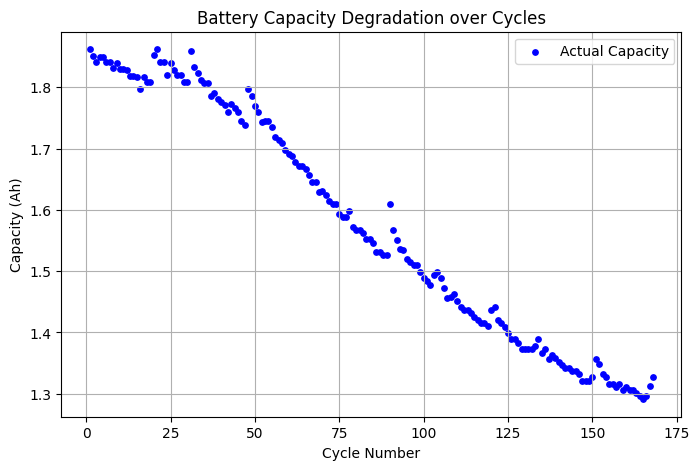

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(battery['cycle'], battery['capacity'], color='blue', s=15, label='Actual Capacity')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title('Battery Capacity Degradation over Cycles')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

# Exponential model define
def exp_model(cycle, a, b, c):
    return a * np.exp(-b * cycle) + c

cycles = battery['cycle'].values
capacity = battery['capacity'].values

# curve fit koro, initial guess p0=[a, b, c]
params, covariance = curve_fit(exp_model, cycles, capacity, p0=[2, 0.005, 1], maxfev=5000)
a, b, c = params
print(f"Fitted parameters: a={a:.4f}, b={b:.6f}, c={c:.4f}")

# Fitted curve theke prediction
capacity_pred_exp = exp_model(cycles, a, b, c)

# RMSE calculate
rmse_exp = np.sqrt(mean_squared_error(capacity, capacity_pred_exp))
print(f"Exponential fit RMSE: {rmse_exp:.5f}")

Fitted parameters: a=7.6198, b=0.000534, c=-5.7095
Exponential fit RMSE: 0.02922


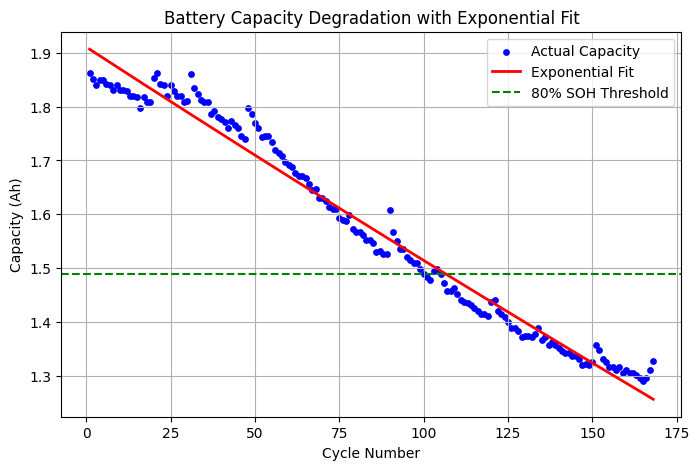

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(cycles, capacity, color='blue', s=15, label='Actual Capacity')
plt.plot(cycles, capacity_pred_exp, color='red', linewidth=2, label='Exponential Fit')
plt.axhline(y=0.8*capacity[0], color='green', linestyle='--', label='80% SOH Threshold')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title('Battery Capacity Degradation with Exponential Fit')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Polynomial fit (degree 3)
poly_coeffs = np.polyfit(cycles, capacity, deg=3)
poly_model = np.poly1d(poly_coeffs)

capacity_pred_poly = poly_model(cycles)

rmse_poly = np.sqrt(mean_squared_error(capacity, capacity_pred_poly))
print(f"Polynomial fit RMSE: {rmse_poly:.5f}")
print(f"Exponential fit RMSE: {rmse_exp:.5f}")

Polynomial fit RMSE: 0.01748
Exponential fit RMSE: 0.02922


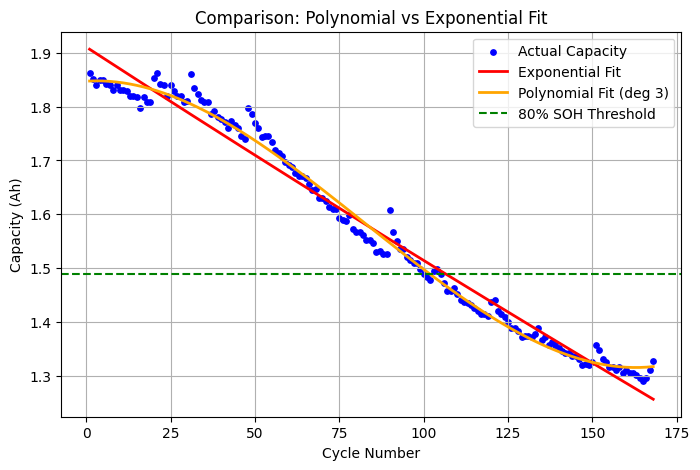

In [9]:
# Comparison graph - both fits together
plt.figure(figsize=(8,5))
plt.scatter(cycles, capacity, color='blue', s=15, label='Actual Capacity')
plt.plot(cycles, capacity_pred_exp, color='red', linewidth=2, label='Exponential Fit')
plt.plot(cycles, capacity_pred_poly, color='orange', linewidth=2, label='Polynomial Fit (deg 3)')
plt.axhline(y=0.8*capacity[0], color='green', linestyle='--', label='80% SOH Threshold')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title('Comparison: Polynomial vs Exponential Fit')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
threshold = 0.8 * capacity[0]

# Polynomial fit to EOL cycle
cycle_range = np.linspace(cycles.min(), cycles.max()*1.5, 5000)
poly_vals = poly_model(cycle_range)


eol_index = np.where(poly_vals <= threshold)[0]

if len(eol_index) > 0:
    eol_cycle_poly = cycle_range[eol_index[0]]
    print(f"Battery will reach 80% SOH after approximately {eol_cycle_poly:.0f} cycles (Polynomial model)")
else:
    print("Threshold not reached within the extrapolated range")

# threshold = a*exp(-b*cycle) + c  =>  cycle = -(1/b) * ln((threshold - c)/a)
eol_cycle_exp = -(1/b) * np.log((threshold - c)/a)
print(f"Battery will reach 80% SOH after approximately {eol_cycle_exp:.0f} cycles (Exponential model)")

Battery will reach 80% SOH after approximately 102 cycles (Polynomial model)
Battery will reach 80% SOH after approximately 106 cycles (Exponential model)


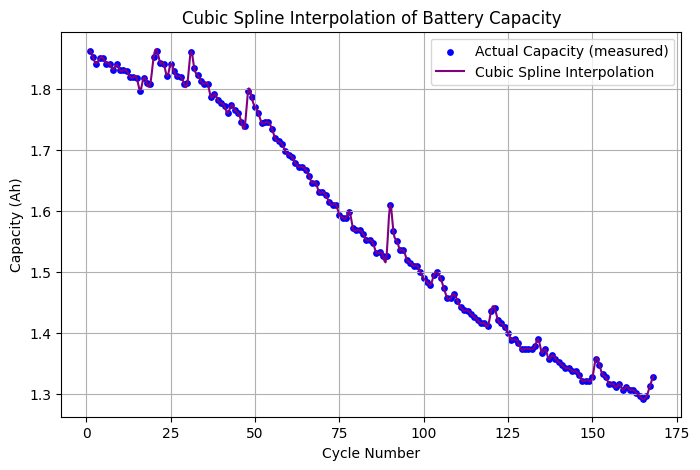

In [12]:
from scipy.interpolate import CubicSpline

# Cubic spline fit
cs = CubicSpline(cycles, capacity)

# cycle range
dense_cycles = np.linspace(cycles.min(), cycles.max(), 500)
capacity_spline = cs(dense_cycles)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(cycles, capacity, color='blue', s=15, label='Actual Capacity (measured)')
plt.plot(dense_cycles, capacity_spline, color='purple', linewidth=1.5, label='Cubic Spline Interpolation')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title('Cubic Spline Interpolation of Battery Capacity')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Example
example_cycle = 75.5
estimated_capacity = cs(example_cycle)
print(f"Estimated capacity at cycle {example_cycle}: {estimated_capacity:.4f} Ah")

Estimated capacity at cycle 75.5: 1.5899 Ah


In [14]:
# Newton's Forward Difference Interpolation

def forward_diff_table(x, y):
    n = len(y)
    diff_table = np.zeros((n, n))
    diff_table[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            diff_table[i][j] = diff_table[i+1][j-1] - diff_table[i][j-1]
    return diff_table

def newton_forward_interpolate(x, y, x_val, num_points=5):

    idx = np.searchsorted(x, x_val)
    start = max(0, idx - num_points//2)
    end = min(len(x), start + num_points)
    x_sub = x[start:end]
    y_sub = y[start:end]

    h = x_sub[1] - x_sub[0]   #
    diff_table = forward_diff_table(x_sub, y_sub)

    p = (x_val - x_sub[0]) / h
    result = diff_table[0][0]
    p_term = 1
    fact = 1
    for k in range(1, len(x_sub)):
        p_term *= (p - (k-1))
        fact *= k
        result += (p_term / fact) * diff_table[0][k]

    return result

# Test same example, cycle 75.5
example_cycle = 75.5
newton_result = newton_forward_interpolate(cycles, capacity, example_cycle)
print(f"Newton Forward Difference estimate at cycle {example_cycle}: {newton_result:.4f} Ah")
print(f"Cubic Spline estimate at cycle {example_cycle}: {cs(example_cycle):.4f} Ah")

Newton Forward Difference estimate at cycle 75.5: 1.5905 Ah
Cubic Spline estimate at cycle 75.5: 1.5899 Ah


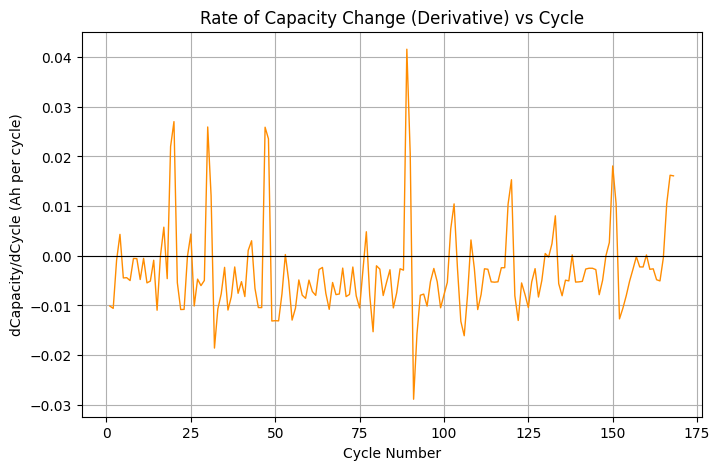

Cycles with sudden capacity drop (possible early warning): [91]


In [15]:
# Numerical differentiation - capacity rate of change
slope = np.gradient(capacity, cycles)

plt.figure(figsize=(8,5))
plt.plot(cycles, slope, color='darkorange', linewidth=1)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('Cycle Number')
plt.ylabel('dCapacity/dCycle (Ah per cycle)')
plt.title('Rate of Capacity Change (Derivative) vs Cycle')
plt.grid(True)
plt.show()

# Sudden large drops
threshold_slope = slope.mean() - 2*slope.std()
sudden_points = cycles[slope < threshold_slope]
print(f"Cycles with sudden capacity drop (possible early warning): {sudden_points}")

In [16]:
# Check current dataset
print(df.columns.tolist())

['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh', 'rul']


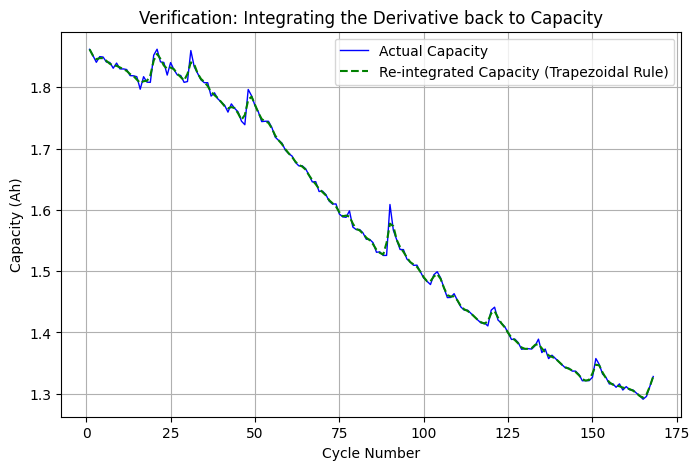

RMSE between actual and re-integrated capacity: 0.00518


In [17]:
from scipy.integrate import cumulative_trapezoid

# Step 13 er slope (derivative) ke abar integrate kore dekhi original capacity curve pai kina
integrated_capacity = capacity[0] + cumulative_trapezoid(slope, cycles, initial=0)

plt.figure(figsize=(8,5))
plt.plot(cycles, capacity, color='blue', linewidth=1, label='Actual Capacity')
plt.plot(cycles, integrated_capacity, color='green', linestyle='--', linewidth=1.5, label='Re-integrated Capacity (Trapezoidal Rule)')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title('Verification: Integrating the Derivative back to Capacity')
plt.legend()
plt.grid(True)
plt.show()

# Error check koro
integration_rmse = np.sqrt(mean_squared_error(capacity, integrated_capacity))
print(f"RMSE between actual and re-integrated capacity: {integration_rmse:.5f}")

In [18]:
import pandas as pd

summary = pd.DataFrame({
    'Method': ['Exponential Curve Fit', 'Polynomial Curve Fit (deg 3)',
               'Newton Forward Interpolation (validation)', 'Cubic Spline Interpolation (validation)',
               'Derivative-Integration Consistency Check'],
    'Metric': ['RMSE', 'RMSE', 'Estimated value at cycle 75.5', 'Estimated value at cycle 75.5', 'RMSE'],
    'Value': [rmse_exp, rmse_poly, newton_result, cs(75.5), integration_rmse]
})

print(summary)

eol_summary = pd.DataFrame({
    'Model': ['Exponential', 'Polynomial'],
    'Predicted EOL Cycle (80% SOH)': [eol_cycle_exp, eol_cycle_poly]
})

print(eol_summary)

# CSV file hisebe save koro - final report er jonno
summary.to_csv('project_summary_results.csv', index=False)
eol_summary.to_csv('eol_predictions.csv', index=False)
print("Files saved!")

                                      Method                         Metric  \
0                      Exponential Curve Fit                           RMSE   
1               Polynomial Curve Fit (deg 3)                           RMSE   
2  Newton Forward Interpolation (validation)  Estimated value at cycle 75.5   
3    Cubic Spline Interpolation (validation)  Estimated value at cycle 75.5   
4   Derivative-Integration Consistency Check                           RMSE   

                Value  
0            0.029218  
1            0.017481  
2            1.590464  
3  1.5899442852728225  
4            0.005181  
         Model  Predicted EOL Cycle (80% SOH)
0  Exponential                     106.463539
1   Polynomial                     101.771554
Files saved!


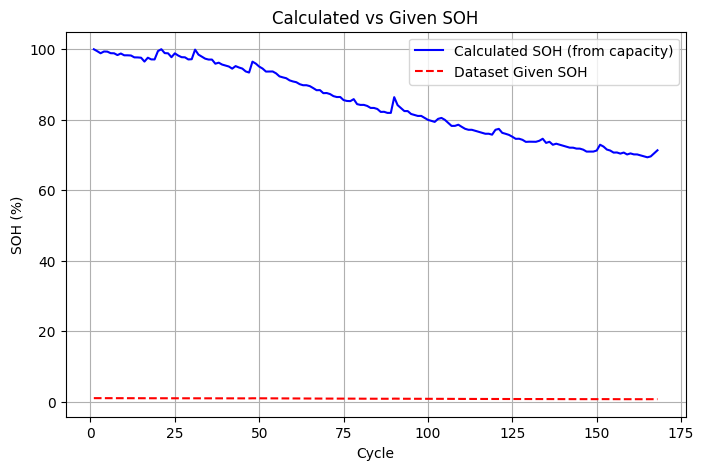

In [19]:
# calculated SOH vs dataset given SOH compare
calculated_soh = (capacity / capacity[0]) * 100
given_soh = battery['soh'].values

plt.figure(figsize=(8,5))
plt.plot(cycles, calculated_soh, label='Calculated SOH (from capacity)', color='blue')
plt.plot(cycles, given_soh, label='Dataset Given SOH', color='red', linestyle='--')
plt.xlabel('Cycle')
plt.ylabel('SOH (%)')
plt.title('Calculated vs Given SOH')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print(battery['soh'].head(10))
print(battery['soh'].min(), battery['soh'].max())

0    1.000000
1    0.994568
2    0.988631
3    0.993599
4    0.993263
5    0.988808
6    0.988531
7    0.983452
8    0.987953
9    0.982837
Name: soh, dtype: float64
0.6934217422519943 1.0000929934484686


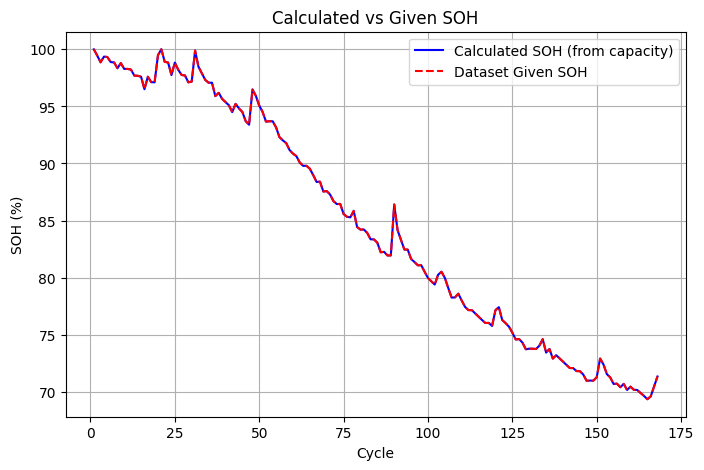

RMSE between calculated SOH and given SOH: 0.0000


In [21]:
given_soh = battery['soh'].values * 100   # fraction -> percentage

plt.figure(figsize=(8,5))
plt.plot(cycles, calculated_soh, label='Calculated SOH (from capacity)', color='blue')
plt.plot(cycles, given_soh, label='Dataset Given SOH', color='red', linestyle='--')
plt.xlabel('Cycle')
plt.ylabel('SOH (%)')
plt.title('Calculated vs Given SOH')
plt.legend()
plt.grid(True)
plt.show()

# Difference check
soh_diff_rmse = np.sqrt(mean_squared_error(calculated_soh, given_soh))
print(f"RMSE between calculated SOH and given SOH: {soh_diff_rmse:.4f}")